In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import src.tetraphymac.logical_channels as lc
import src.tetraphymac.physical_channels as pc
import src.tetraphymac.modulation as tetraMod
from numpy import pi as pi
from numpy import complex64, int16, float64, uint8, cos, sin, log10
from numpy.typing import NDArray

# Propagation Models
There are 4 types of propagation models defined in 392-2 V2.4.2:
1. STATIC
2. TU50
3. HT200
4. EQ200
   
MS equipment falls into 3 classes
1. Class B: Equipment for built-up/urban areas, meeting Static and TU50
2. Class A: Equipment optimized for urban areas and hilly/mountainous terian meeting: Static, TU50, HT200
3. Class E: Equipment contains an equalizer (not BS equipment), specified for Static, TU50, HT200 (PACQ only), and EQ200 conditions

Specific performance requirements based on burst type apply for MER and BER for confromance/meeting propagation types for a given class.

## TETRA implementation
Since all the propagation models are defined in a similar way: delay, scale, tap-gain-process,
a generic propagation model class can be designed as follows:
1. Propagation Model
    1. Tap #1
        1. Delay Filter and/or Ampltiude scaling: a1*H1(t), (if delay is zero H(t) is 1)
        2. Tap-Gain-Process S1(t)
    2. Tap #2
       1. Delay Filter and/or Ampltiude scaling: a1*H2(t), (if delay is zero H(t) is 1)
       2. Tap-Gain-Process S2(t)
    3. Tap #N ...

With an input signal of x(t), the output is:
$$y(t)= \sum_{k=1}^{N}S_{k}(t)\times [x(t)\ast (a_{n}\times H_{n}(t))]$$

Note that the convolution/filtering result is delay compared to the original signal with zeros infront, and the output is fully flushed with zeros, thus leading to an output that is longer than the input which.

## Tap Gain Process Implementation
The specification denotes that for a CLASS type tap-gain-process or tgp for short, the resulting PSD follows the classic Clark's/Jake's "U" shaped doppler spectrum, which is well known.

This PSD arrises from the idea that the received signal can be thought of as purely multi-path, no LOS component, and comprised of the combination of numerous mutlipath rays coming all directions off of many reflecting of numerous objects from isotropic scattering. The resulting signal at the receiver is the combination of all these plane waves and thus has real and imaginary components which are uncorrelated zero mean (because no LOS) gaussian random variables. 

Thus the channel envelope has a rayleigh PDF, because it is the magnitude of a complex number whoses components are indepdent, zero mean. The amount of doppler shift then affects the speed/variability, in turn the coherence time, in the fading as well the PSD width/shape.

### Implementing tap-gain-process / rayleigh fading
There are a few ways to generate the tap-gain-process, but a simple, well behaved deterministic version has been developed though the sum of cosines. This method is deterministic and has been improved over time from Jake's original implementation to improve the statistics to agree better with the expected. There are some newer alternative versions optimized for hardware implementation, but the method developed by Zheng and Xiao in `Improved Models for the Generation of Multiple Uncorrelated Rayleigh Fading Waveforms`, 2002, is sufficent for this application. The basis is a complex gain of Z(t) is as follows taken from Zheng and Xiao:
$$ Z(t) = Z_c(t) + jZ_s(t)$$
$$Z_c(t) = \sqrt{\frac{2}{M}}\sum_{n=1}^{n=1M}cos(\omega_dtcos(\alpha_n)+ \phi_n)$$
$$Z_s(t) = \sqrt{\frac{2}{M}}\sum_{n=1}^{M}sin(\omega_dtsin(\alpha_n)+ \varphi_n)$$
$$\alpha_n = \frac{2\pi n-\pi+\theta }{4M},   n=1,2,...,M$$
- with uniform indepedent random variables: $\theta, \phi_n, \varphi_n$, distrubuted on: $[-\pi, \pi)$
- Higher M values improve the agreeance between the resulting statistics and PSD and the expected at the cost of computation amount.
Since the coherence time is quite slow compared to sample period of 11.52Msps, instead I will sample at few khz, which is plenty for the doppler frequencies involved for TETRA, providing many x oversampling.

Then the result will be interpolated with an FIR low pass and upfirdn polyphase upsampling to the full rate to reduce the computational requirements


In [3]:
def class_PDS(f, fd):
    fd = float(fd)
    results = np.zeros_like(f, dtype=np.float64)
    mask = np.abs(f) < fd
    x = f[mask]/fd
    x = np.clip(x, -1 + 1e-12, 1 - 1e-12)
    results[mask] = 1/(pi * fd * np.sqrt(1 - (x*x)))
    return results

In [4]:
def get_fd(freq, mode: str, v: float | None = None):
    wl = (3E8/ freq)  # lambda/wavelength in Meters
    if mode == "STATIC":
        assert v is not None
        fd = (v / 3.6) / wl  # Hz
    else:
        assert mode in ("STATIC", "TU50", "HT200", "EQ200")
        if mode == "TU50":
            if freq < 380E6 or freq > 520E6:
                x = (20 * wl) * 3.6  # km/h
            else:
                x = 50  # km/h
        elif mode in ("EQ200", "HT200"):
            if freq < 380E6 or freq > 520E6:
                x = (80 * wl) * 3.6  # km/h
            else:
                x = 200  # km/h
        fd = (x / 3.6) / wl  # Hz
    return fd

In [5]:
freq = 910E8
mode = "TU50"
fd = get_fd(freq, mode)
print(fd)
fd = get_fd(freq, "EQ200")
print(fd)

20.0
80.0


In [6]:
class jakes_doppler_zheng_xiao:
    # Designed based off the "Improved Models for the Generation of Multiple
    # Uncorrelated Rayleigh Fading Waveforms" by Zhen and Xiao, 2002
    def __init__(self, fs, fd, M, seed: int = 5223):
        self.wd = (fd * 2 * pi)
        self.M = M

        # Generate random phi, psi, theta values
        self.gen = np.random.SeedSequence(seed)
        phi_seed, psi_seed, theta_seed = self.gen.spawn(3)
        self.phi_gen = np.random.Generator(np.random.PCG64(phi_seed))
        self.psi_gen = np.random.Generator(np.random.PCG64(psi_seed))
        self.theta_gen = np.random.Generator(np.random.PCG64(theta_seed))
        
        self.phi_n = self.phi_gen.uniform(low=-pi, high=pi, size=self.M)[:, None]
        self.psi_n = self.psi_gen.uniform(low=-pi, high=pi, size=self.M)[:, None]
        self.theta_n = self.theta_gen.uniform(low=-pi, high=pi, size=self.M)
    
        self.alpha_n = (2*pi*(np.arange(1, self.M+1)) - pi + self.theta_n)/(4*self.M)
        self.wd_cos_alpha_n = self.wd * np.cos(self.alpha_n)[:, None]
        self.wd_sin_alpha_n = self.wd * np.sin(self.alpha_n)[:, None]

    def evaluate(self, t):
        # Z (Result) = a + jb
        a = np.sum(np.cos((t * self.wd_cos_alpha_n) + self.phi_n), axis=0)
        b = np.sum(np.sin((t * self.wd_sin_alpha_n) + self.psi_n), axis=0)
        z = (np.sqrt(2/self.M))*(a + 1j*b)
        return z
        

424000
80.0


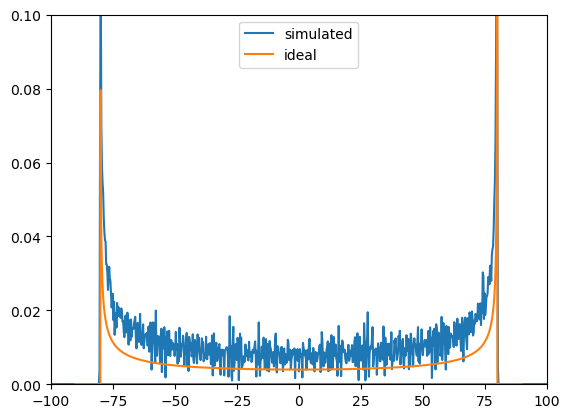

In [7]:
fc = 4E3
fs = 2e3
dop = jakes_doppler_zheng_xiao(fs, fd, 256)

t = np.arange(0.0, 106, 1/(fc))

y = dop.evaluate(t)
print(y.size)

f, P = sp.signal.welch(
    y,
    fs=fc,
    nperseg=2**14,
    noverlap=2**13,
    return_onesided=False,
    scaling="density"
)

f_test= np.arange(-fd-10, fd+10.1, 0.1)
y_ideal = class_PDS(f_test, fd)

plt.figure()
plt.plot(f, P, label="simulated")
plt.plot(f_test, y_ideal, label="ideal")
plt.xlim(-100, 100)
plt.ylim(0, 0.1)
plt.legend()
print(fd)

Text(0.5, 1.0, '100kHz vs 10kHz simulation of doppler for 80Hz')

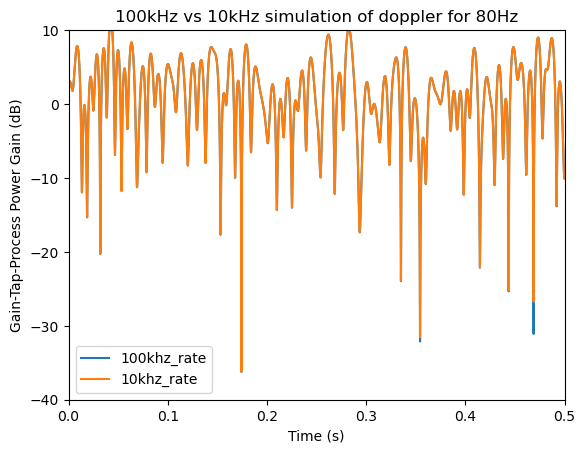

In [8]:
# interpolation validation/comparison
fs1 = 100E3
fs2 = 10.0E3
dop_full_rate = jakes_doppler_zheng_xiao(fs1, fd, 256)
dop_interp = jakes_doppler_zheng_xiao(fs2, fd, 256)
t1 = np.arange(0.0, 1, 1/fs1)
t2 = np.arange(0.0, 1, 1/fs2)

y1 = dop_full_rate.evaluate(t1)
y2 = dop_full_rate.evaluate(t2)

plt.figure()
plt.plot(t1, 10*np.log10(np.abs(y1)**2 + 1E-300), label="100khz_rate")
plt.plot(t2, 10*np.log10(np.abs(y2)**2 + 1E-300), label="10khz_rate")
plt.legend()
plt.xlim(0, 0.5)
plt.ylabel("Gain-Tap-Process Power Gain (dB)")
plt.xlabel("Time (s)")
plt.ylim(-40, 10)
plt.title("100kHz vs 10kHz simulation of doppler for 80Hz")

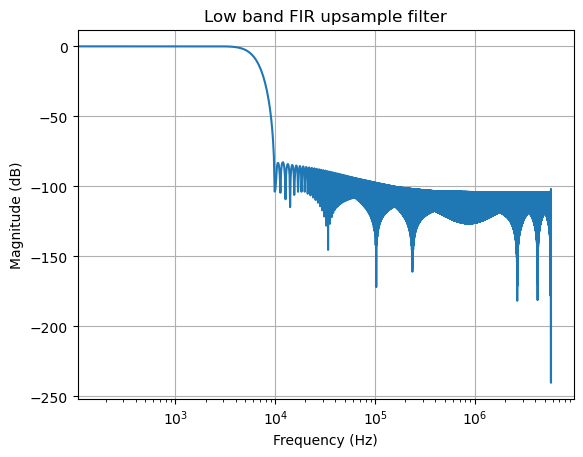

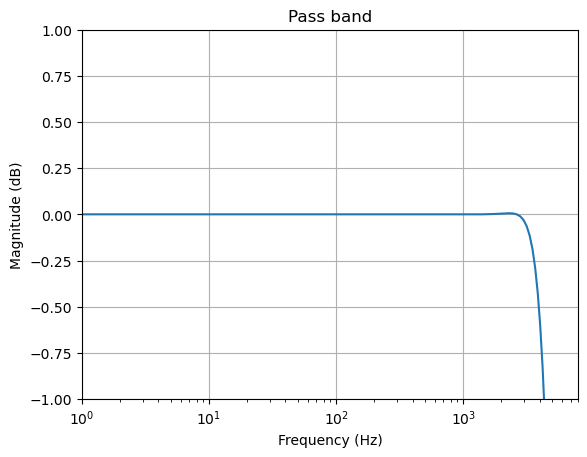

In [9]:
# Generate interpolation fir
import scipy as sp
Fs = 11520000
fs_low = fs2
fs = 11_520_000
l_inter = sp.signal.remez(8192, [0, 2800.0, fs_low, fs/2], [1, 0], weight=[1, 100], fs=fs)
dc_gain = np.sum(l_inter)
l_inter /= dc_gain
N_fft = 16384*4
H = sp.fft.rfft(l_inter, N_fft)
f = sp.fft.rfftfreq(N_fft, d=1/Fs)

plt.figure()
plt.semilogx(f, 20*np.log10(np.abs(H) + 1e-12))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Low band FIR upsample filter")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogx(f, 20*np.log10(np.abs(H) + 1e-12))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Pass band")
plt.grid(True)
plt.xlim(1, 8E3)
plt.ylim(-1, 1)
plt.show()

1152


Text(0.5, 0, 'Time (s)')

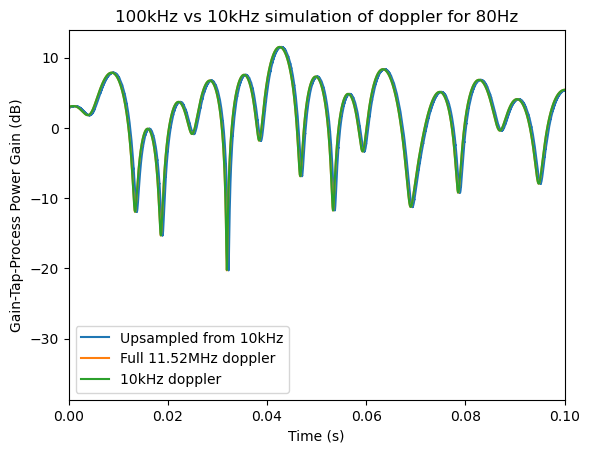

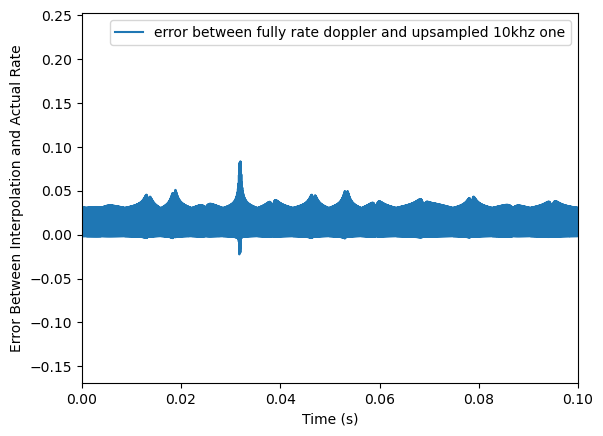

In [10]:
# Compare results
fs1 = 11.52E6
fs2 = 10.0E3
dop_full_rate = jakes_doppler_zheng_xiao(fs1, fd, 256)
dop_interp = jakes_doppler_zheng_xiao(fs2, fd, 256)
t1 = np.arange(0.0, 0.2, 1/fs1)
t2 = np.arange(0.0, 0.2, 1/fs2)

y1 = dop_full_rate.evaluate(t1)
y2 = dop_full_rate.evaluate(t2)

factor = int(fs1) // int(fs2)
out = np.empty(shape=(y2.size * factor), dtype=np.complex128)
h_coef = np.complex128(l_inter*factor)

t2_warmup = np.arange(-0.1, 0, 1/fs2)
y2_warmup = dop_full_rate.evaluate(t2_warmup)


print(factor)
mem_len = int(np.ceil((h_coef.size-1) / factor))


# Warmup
filt_hist = np.empty(shape=mem_len, dtype=np.complex128)
samples = np.empty(shape=(y2_warmup.size + mem_len), dtype=np.complex128)
samples[:mem_len] = filt_hist
samples[mem_len:] = y2_warmup
_ = sp.signal.upfirdn(h_coef, samples, up=factor)
filt_hist = samples[-mem_len:]

# Now filter
samples = np.empty(shape=(y2.size + mem_len), dtype=np.complex128)
samples[:mem_len] = filt_hist
samples[mem_len:] = y2
filt_hist = samples[-mem_len:]
out = sp.signal.upfirdn(h_coef, samples, up=factor)

delay_interp = (h_coef.size - 1) //2

y3 = out[mem_len*factor: mem_len*factor + y2.size*factor]

plt.figure()
plt.plot(t1, 10*np.log10(np.abs(y3)**2 + 1E-300), label="Upsampled from 10kHz")
plt.plot(t1, 10*np.log10(np.abs(y1)**2 + 1E-300), label="Full 11.52MHz doppler")
plt.plot(t2, 10*np.log10(np.abs(y2)**2 + 1E-300), label="10kHz doppler")
plt.legend()
plt.xlim(0, 0.1)
plt.ylabel("Gain-Tap-Process Power Gain (dB)")
plt.xlabel("Time (s)")
plt.title("100kHz vs 10kHz simulation of doppler for 80Hz")

plt.figure()
y1_out_len = y3.size - delay_interp
error_db = 10*np.log10(np.abs(y1[:y1_out_len])**2 + 1E-300) - 10*np.log10(np.abs(y3[delay_interp:])**2 + 1E-300)
plt.plot(t1[:y1_out_len], error_db, label="error between fully rate doppler and upsampled 10khz one")
plt.legend()
plt.xlim(0, 0.1)
plt.ylabel("Error Between Interpolation and Actual Rate")
plt.xlabel("Time (s)")

## Delay Control
There are many methods for generating a fractional delay of sampled data. Of course when the sampling rate is smaller than the delay, the delay decomposes into a integer-sample delay and a fractional delay. For the TETRA simulation rate of 11.52 Msps, much of the delay is integer samples, for that portion of the delay, we simply shift the data in time w.r.t. to the original signal. 

To acheive a fractional delay, there are many ways to do that, Laakso, et al. `Splitting the Unit Delay: Tools for fractional delay filter design`, 1996, provides an exhaustive survey of contemprary methods to generate fractional delays. However, amoung the methods for fractional delay, the simplest is a Lagrange FIR delay.
### Lagrange Interpolator
The main limitation of the Lagrange FIR is it's narrowbanded response, which even with higher filter lengths (4-6) does not change much. Note that the lagrange polynomial interpolation is not stable/accurate for higher orders. 

Another limitation of the Lagrange FIR is that variable delay is not possible without recomputing the filter coefficents compared to Farrow FIR structures which are often used in real-time hw simulation or modems.

However, because the TETRA simulation rate is at 11.52Msps and the bw of interest is at the very most only 1/10th of that for harmonics and wideband noise, a Lagrange order 3, Length of 4, provides an acceptable usable bandwidth of 0.2.

If in the future a higher bandwidth, or lower sampling rate, is used then an alternative FIR filter design method would have to be used. For now the coefficents are defined as follows as taken from Laakso, et al.:
$$ h(n) = \prod_{\frac{k=0}{k\neq n}}^{N}\frac{D-k}{n-k}\, for\,   n=0,1,2,...N$$

In [11]:
def gen_lagrange_delay(D: float, N:int = 3):
    h_n = np.zeros(shape=N+1, dtype=np.float64)
    print(D)
    for n in range(N+1):
        n_k = 1
        k_vals = [x for x in range(N+1) if x != n]
        for k in k_vals:
            n_k *= ((D-k)/(n-k))
        h_n[n] = n_k
    return h_n

In [12]:
def split_delay(fs, delay, N):
    delay_total = (delay) * fs
    filter_int_delay = N/2

    int_delay = int(np.round(delay_total - filter_int_delay))
    filter_frac_delay = delay_total - int_delay - filter_int_delay

    if filter_frac_delay >= 0.5:
        int_delay += 1
        filter_frac_delay -= 1.0
    elif filter_frac_delay < -0.5:
        int_delay -= 1
        filter_frac_delay += 1.0

    filter_total_delay = filter_frac_delay + filter_int_delay
    h_coef = gen_lagrange_delay(filter_total_delay, N)

    return int_delay, h_coef


In [13]:
delay_us = 5.0E-6
fs = 11_520_000.0
int_delay, delay_h = split_delay(fs, delay_us, 3)
print(int_delay)
print(delay_h)

1.6000000000000014
56
[-0.056  0.448  0.672 -0.064]


Text(0, 0.5, 'Group delay error vs expected (us)')

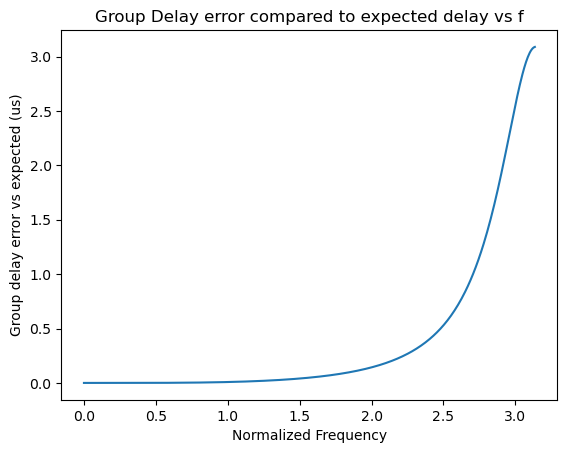

In [15]:
w, gd = sp.signal.group_delay((delay_h, 1))
plt.plot(w, gd-(1.6))
plt.title("Group Delay error compared to expected delay vs f")
plt.xlabel("Normalized Frequency")
plt.ylabel("Group delay error vs expected (us)")